In [ ]:
pip install transformers sentence-transformers torch pandas numpy scikit-learn matplotlib


In [ ]:
models = {
    "all-MiniLM-L6-v2": "sentence-transformers/all-MiniLM-L6-v2",
    "all-mpnet-base-v2": "sentence-transformers/all-mpnet-base-v2",
    "paraphrase-MiniLM-L12-v2": "sentence-transformers/paraphrase-MiniLM-L12-v2",
    "paraphrase-mpnet-base-v2": "sentence-transformers/paraphrase-mpnet-base-v2"
}
sentence_pairs = [
    ("A man is playing guitar", "A person plays a musical instrument"),
    ("The cat is sleeping", "A dog is barking"),
    ("She is cooking food", "She prepares a meal"),
    ("The sky is blue", "The ocean is vast")
]

ground_truth = [0.9, 0.1, 0.85, 0.4]  # human similarity scores


In [ ]:
import time
import numpy as np
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import mean_squared_error

results = []

for name, model_id in models.items():
    model = SentenceTransformer(model_id)

    start = time.time()
    preds = []

    for (s1, s2) in sentence_pairs:
        emb1 = model.encode(s1, convert_to_tensor=True)
        emb2 = model.encode(s2, convert_to_tensor=True)
        sim = util.cos_sim(emb1, emb2).item()
        preds.append(sim)

    inference_time = (time.time() - start) / len(sentence_pairs)

    accuracy = 1 - mean_squared_error(ground_truth, preds)
    size_mb = sum(p.numel() for p in model.parameters()) * 4 / 1e6
    embedding_dim = model.get_sentence_embedding_dimension()

    results.append([
        name, accuracy, size_mb, inference_time, embedding_dim
    ])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
import pandas as pd

df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Model_Size_MB", "Inference_Time", "Embedding_Dim"
])

df


,Model,Accuracy,Model_Size_MB,Inference_Time,Embedding_Dim
0,all-MiniLM-L6-v2,0.977803,90.852864,0.094670,384
1,all-mpnet-base-v2,0.973230,437.945856,0.172348,768
2,paraphrase-MiniLM-L12-v2,0.918078,133.440000,0.056113,384
3,paraphrase-mpnet-base-v2,0.959795,437.945856,0.157483,768


In [ ]:
weights = np.array([0.35, 0.20, 0.20, 0.25])
criteria = np.array([1, -1, -1, 1])  # benefit=1, cost=-1


In [ ]:
def topsis(matrix, weights, criteria):
    norm = matrix / np.sqrt((matrix**2).sum(axis=0))
    weighted = norm * weights

    ideal_best = np.max(weighted * criteria, axis=0)
    ideal_worst = np.min(weighted * criteria, axis=0)

    dist_best = np.sqrt(((weighted - ideal_best)**2).sum(axis=1))
    dist_worst = np.sqrt(((weighted - ideal_worst)**2).sum(axis=1))

    score = dist_worst / (dist_best + dist_worst)
    return score


In [ ]:
decision_matrix = df.iloc[:, 1:].values
df["TOPSIS_Score"] = topsis(decision_matrix, weights, criteria)
df.sort_values("TOPSIS_Score", ascending=False)


,Model,Accuracy,Model_Size_MB,Inference_Time,Embedding_Dim,TOPSIS_Score
2,paraphrase-MiniLM-L12-v2,0.918078,133.440000,0.056113,384,0.646848
0,all-MiniLM-L6-v2,0.977803,90.852864,0.094670,384,0.635400
3,paraphrase-mpnet-base-v2,0.959795,437.945856,0.157483,768,0.620727
1,all-mpnet-base-v2,0.973230,437.945856,0.172348,768,0.617317


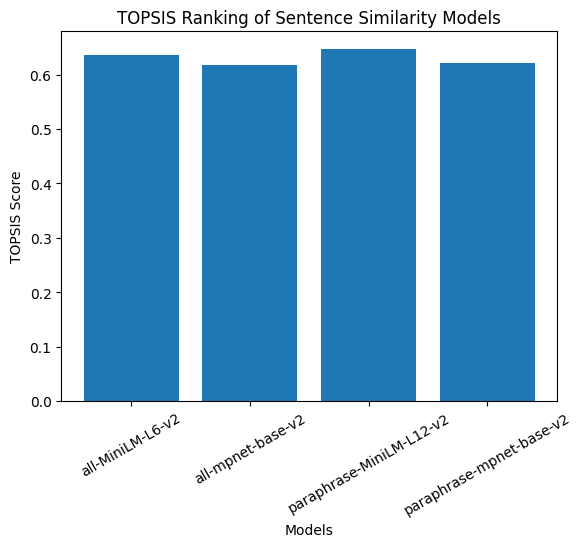

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df["Model"], df["TOPSIS_Score"])
plt.xlabel("Models")
plt.ylabel("TOPSIS Score")
plt.title("TOPSIS Ranking of Sentence Similarity Models")
plt.xticks(rotation=30)
plt.show()


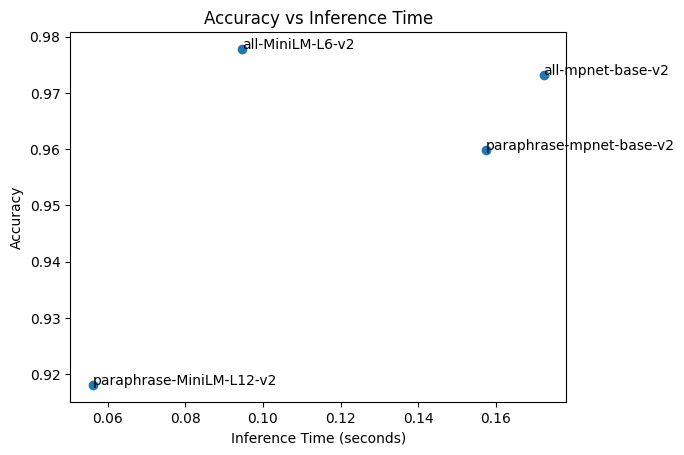

In [ ]:
plt.figure()
plt.scatter(df["Inference_Time"], df["Accuracy"])
for i, model in enumerate(df["Model"]):
    plt.text(df["Inference_Time"][i], df["Accuracy"][i], model)

plt.xlabel("Inference Time (seconds)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Inference Time")
plt.show()


In [ ]:
best_model = SentenceTransformer("sentence-transformers/paraphrase-MiniLM-L12-v2")

emb1 = best_model.encode("How are you?")
emb2 = best_model.encode("How do you do?")
similarity = util.cos_sim(emb1, emb2)

print(similarity.item())


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


0.5724583864212036


In [15]:


from google.colab import drive
import os
import matplotlib.pyplot as plt

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/TOPSIS_Sentence_Similarity"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/graphs", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/data", exist_ok=True)

df.to_csv(f"{PROJECT_DIR}/data/topsis_results.csv", index=False)

plt.figure()
plt.bar(df["Model"], df["TOPSIS_Score"])
plt.xlabel("Models")
plt.ylabel("TOPSIS Score")
plt.title("TOPSIS Ranking of Models")
plt.xticks(rotation=30)
plt.savefig(f"{PROJECT_DIR}/graphs/topsis_scores.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure()
plt.scatter(df["Inference_Time"], df["Accuracy"])
for i, model in enumerate(df["Model"]):
    plt.text(df["Inference_Time"][i], df["Accuracy"][i], model)
plt.xlabel("Inference Time (seconds)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Inference Time")
plt.savefig(f"{PROJECT_DIR}/graphs/accuracy_vs_time.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure()
plt.bar(df["Model"], df["Model_Size_MB"])
plt.xlabel("Models")
plt.ylabel("Model Size (MB)")
plt.title("Model Size Comparison")
plt.xticks(rotation=30)
plt.savefig(f"{PROJECT_DIR}/graphs/model_size.png", dpi=300, bbox_inches="tight")
plt.close()




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')